# 02 — Training Replicas

For each window pair `(A, B)` this notebook:

1. Tunes **MLP hyperparameters per window** using Optuna with time-aware validation, optimising PR-AUC.
2. Trains **R MLP replicas** per window using stratified bootstrap sampling and different random seeds.
3. Uses ordinal categorical inputs from notebook 00 and a noisy-quantile transform on the numeric block.
4. Aggregates predictions on the shared evaluation slice and defines the flagged set `F_{A,B}` from the top `K_FRAC` of `max(p_hat_A, p_hat_B)`.

**Input:** `data/processed/`, `data/windows/window_config.json`  
**Output per pair:** `data/models/pair_{i:02d}/`


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
%pip install -q optuna torch joblib pyarrow scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 33.7 MB/s eta 0:00:00


In [3]:
import json
import copy
import math
import joblib
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import QuantileTransformer
import optuna
from optuna.samplers import TPESampler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

WORKSPACE  = Path('/content/drive/MyDrive/Home Insurance MLP')
PROC_DIR   = WORKSPACE / 'data' / 'processed'
WIN_DIR    = WORKSPACE / 'data' / 'windows'
MODEL_DIR  = WORKSPACE / 'data' / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

N_TRIALS        = 10
CV_N_SPLITS     = 3
VALID_FRAC      = 0.20
MAX_EPOCHS      = 100
PATIENCE        = 10
BATCH_SIZE      = 1024
EVAL_BATCH_SIZE = 4096
N_QUANTILES     = 1024
SEED_BASE       = 42

MLP_SEARCH_SPACE = {
    'n_blocks':     ('int', 1, 4),
    'd_block':      ('pow2', 7, 11),
    'dropout':      ('float', 0.0, 0.75),
    'lr':           ('logfloat', 1e-5, 1e-3),
    'weight_decay': ('logfloat', 1e-6, 1e-3),
}

print(f'N_TRIALS={N_TRIALS}, CV_N_SPLITS={CV_N_SPLITS}, PATIENCE={PATIENCE}, BATCH_SIZE={BATCH_SIZE}')


Device: cuda
N_TRIALS=10, CV_N_SPLITS=3, PATIENCE=10, BATCH_SIZE=1024


In [4]:
X_df = pd.read_parquet(PROC_DIR / 'X.parquet')
X    = X_df.values.astype(np.float32)
Y    = np.load(PROC_DIR / 'Y.npy').astype(np.int8)

with open(PROC_DIR / 'feature_names.json') as f:
    feat_names = json.load(f)

num_cols = feat_names['num']
bin_cols = feat_names['bin']
num_col_idx = [X_df.columns.get_loc(c) for c in num_cols]
bin_col_idx = [X_df.columns.get_loc(c) for c in bin_cols]

with open(WIN_DIR / 'window_config.json') as f:
    config = json.load(f)

R      = config['parameters']['R']
K_FRAC = config['parameters']['K_FRAC']
pairs  = config['pairs']

print(f'X: {X.shape}, Y: {Y.shape}')
print(f'Numeric features: {len(num_col_idx)}  Binary features: {len(bin_col_idx)}')
print(f'R={R}, K_FRAC={K_FRAC}, pairs={len(pairs)}')


X: (260753, 317), Y: (260753,)
Numeric features: 280  Binary features: 37
R=5, K_FRAC=0.1, pairs=5


In [5]:
def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def split_train_valid_time(idx: np.ndarray, valid_frac: float = VALID_FRAC):
    idx = np.asarray(idx, dtype=np.int64)
    cut = max(1, int(len(idx) * (1.0 - valid_frac)))
    cut = min(cut, len(idx) - 1)
    return idx[:cut], idx[cut:]


def stratified_bootstrap(idx: np.ndarray, y: np.ndarray, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    idx = np.asarray(idx, dtype=np.int64)
    pos = idx[y[idx] == 1]
    neg = idx[y[idx] == 0]
    boot_pos = rng.choice(pos, size=len(pos), replace=True) if len(pos) else np.array([], dtype=np.int64)
    boot_neg = rng.choice(neg, size=len(neg), replace=True) if len(neg) else np.array([], dtype=np.int64)
    out = np.concatenate([boot_pos, boot_neg])
    rng.shuffle(out)
    return out.astype(np.int64)


def fit_noisy_quantile_preprocessor(X_train_raw: np.ndarray, num_col_idx: list, bin_col_idx: list, seed: int):
    X_train_raw = np.asarray(X_train_raw, dtype=np.float32)
    X_num = X_train_raw[:, num_col_idx].astype(np.float32)
    X_bin = X_train_raw[:, bin_col_idx].astype(np.float32) if len(bin_col_idx) else np.empty((len(X_train_raw), 0), dtype=np.float32)

    rng = np.random.default_rng(seed)
    noise_scale = X_num.std(axis=0, keepdims=True)
    noise_scale = np.where(noise_scale < 1e-6, 1.0, noise_scale)
    X_num_noisy = X_num + rng.normal(0.0, 1e-3, size=X_num.shape).astype(np.float32) * noise_scale.astype(np.float32)

    qt = QuantileTransformer(
        n_quantiles=min(N_QUANTILES, len(X_num_noisy)),
        output_distribution='normal',
        random_state=seed,
        subsample=int(1e9),
        copy=True,
    )
    qt.fit(X_num_noisy)

    return {
        'qt': qt,
        'num_col_idx': num_col_idx,
        'bin_col_idx': bin_col_idx,
    }


def transform_with_preprocessor(X_raw: np.ndarray, prep: dict) -> np.ndarray:
    X_raw = np.asarray(X_raw, dtype=np.float32)
    X_num = prep['qt'].transform(X_raw[:, prep['num_col_idx']].astype(np.float32)).astype(np.float32)
    if len(prep['bin_col_idx']):
        X_bin = X_raw[:, prep['bin_col_idx']].astype(np.float32)
        return np.concatenate([X_num, X_bin], axis=1).astype(np.float32)
    return X_num.astype(np.float32)


class TabularMLP(nn.Module):
    def __init__(self, input_dim: int, n_blocks: int, d_block: int, dropout: float):
        super().__init__()
        layers = []
        d_in = input_dim
        for _ in range(n_blocks):
            layers.extend([
                nn.Linear(d_in, d_block),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            d_in = d_block
        layers.append(nn.Linear(d_in, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


@torch.no_grad()
def predict_proba(model: nn.Module, X_np: np.ndarray, batch_size: int = EVAL_BATCH_SIZE) -> np.ndarray:
    model.eval()
    probs = []
    for start in range(0, len(X_np), batch_size):
        xb = torch.as_tensor(X_np[start:start + batch_size], dtype=torch.float32, device=DEVICE)
        logits = model(xb)
        probs.append(torch.sigmoid(logits).detach().cpu().numpy())
    return np.concatenate(probs).astype(np.float32)


def fit_single_mlp(X_train: np.ndarray, y_train: np.ndarray, X_valid: np.ndarray, y_valid: np.ndarray, params: dict, seed: int):
    set_all_seeds(seed)

    model = TabularMLP(
        input_dim=X_train.shape[1],
        n_blocks=int(params['n_blocks']),
        d_block=int(params['d_block']),
        dropout=float(params['dropout']),
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(params['lr']),
        weight_decay=float(params['weight_decay']),
    )
    criterion = nn.BCEWithLogitsLoss()

    train_ds = TensorDataset(
        torch.as_tensor(X_train, dtype=torch.float32),
        torch.as_tensor(y_train, dtype=torch.float32),
    )
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

    best_state = copy.deepcopy(model.state_dict())
    best_pr = -np.inf
    best_epoch = -1
    patience_left = PATIENCE

    for epoch in range(MAX_EPOCHS):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        valid_proba = predict_proba(model, X_valid)
        valid_pr = average_precision_score(y_valid, valid_proba)

        if valid_pr > best_pr + 1e-6:
            best_pr = float(valid_pr)
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_left = PATIENCE
        else:
            patience_left -= 1

        if patience_left <= 0:
            break

    model.load_state_dict(best_state)
    return model, best_pr, best_epoch


In [6]:
def sample_mlp_params(trial: optuna.Trial) -> dict:
    return {
        'n_blocks': trial.suggest_int('n_blocks', 1, 4),
        'd_block': 2 ** trial.suggest_int('d_block_exp', 7, 11),
        'dropout': trial.suggest_float('dropout', 0.0, 0.75),
        'lr': trial.suggest_float('lr', 1e-5, 1e-3, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True),
    }


def tune_window(idx_window: np.ndarray, study_seed: int) -> dict:
    idx_window = np.asarray(idx_window, dtype=np.int64)

    def objective(trial: optuna.Trial) -> float:
        params = sample_mlp_params(trial)
        splitter = TimeSeriesSplit(n_splits=CV_N_SPLITS)
        fold_scores = []

        for fold, (tr_rel, va_rel) in enumerate(splitter.split(idx_window)):
            idx_tr = idx_window[tr_rel]
            idx_va = idx_window[va_rel]

            prep = fit_noisy_quantile_preprocessor(X[idx_tr], num_col_idx, bin_col_idx, seed=study_seed + fold)
            X_tr = transform_with_preprocessor(X[idx_tr], prep)
            X_va = transform_with_preprocessor(X[idx_va], prep)

            model, best_pr, best_epoch = fit_single_mlp(
                X_tr,
                Y[idx_tr],
                X_va,
                Y[idx_va],
                params,
                seed=study_seed + fold,
            )
            fold_scores.append(best_pr)

        return float(np.mean(fold_scores))

    sampler = TPESampler(seed=study_seed)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

    return {
        'best_params': study.best_trial.params,
        'best_value': float(study.best_value),
    }


def normalise_best_params(best_trial_params: dict) -> dict:
    return {
        'n_blocks': int(best_trial_params['n_blocks']),
        'd_block': int(2 ** best_trial_params['d_block_exp']),
        'dropout': float(best_trial_params['dropout']),
        'lr': float(best_trial_params['lr']),
        'weight_decay': float(best_trial_params['weight_decay']),
    }


In [7]:
performance_log = []

for p in pairs:
    pid       = p['pair_id']
    pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
    pred_file = pair_dir / 'predictions.npz'
    pair_dir.mkdir(parents=True, exist_ok=True)

    if pred_file.exists():
        data = np.load(pred_file)
        print(f'Pair {pid:02d}: already done, skipping.')
        performance_log.append({
            'pair_id':   pid,
            'pr_auc_A':  float(data['pr_auc_A']),
            'pr_auc_B':  float(data['pr_auc_B']),
            'roc_auc_A': float(data['roc_auc_A']),
            'roc_auc_B': float(data['roc_auc_B']),
            'n_flagged': int(data['flagged_idx'].shape[0]),
        })
        continue

    print(f'\n── Pair {pid:02d}: A_end={p["step_label_A"]}  B_end={p["step_label_B"]} ──')

    idx_A    = np.array(p['idx_A'], dtype=np.int64)
    idx_B    = np.array(p['idx_B'], dtype=np.int64)
    idx_eval = np.array(p['idx_eval'], dtype=np.int64)

    A_tune_path = pair_dir / 'tuned_params_A.json'
    B_tune_path = pair_dir / 'tuned_params_B.json'

    if A_tune_path.exists():
        with open(A_tune_path) as f:
            tune_A = json.load(f)
    else:
        print('  Tuning window A...')
        tune_A = tune_window(idx_A, study_seed=SEED_BASE + pid * 100 + 1)
        with open(A_tune_path, 'w') as f:
            json.dump(tune_A, f, indent=2)

    if B_tune_path.exists():
        with open(B_tune_path) as f:
            tune_B = json.load(f)
    else:
        print('  Tuning window B...')
        tune_B = tune_window(idx_B, study_seed=SEED_BASE + pid * 100 + 2)
        with open(B_tune_path, 'w') as f:
            json.dump(tune_B, f, indent=2)

    params_A = normalise_best_params(tune_A['best_params'])
    params_B = normalise_best_params(tune_B['best_params'])

    idx_A_train_ref, idx_A_valid_ref = split_train_valid_time(idx_A, VALID_FRAC)
    reference_preprocessor = fit_noisy_quantile_preprocessor(X[idx_A_train_ref], num_col_idx, bin_col_idx, seed=SEED_BASE + pid * 1000 + 7)
    joblib.dump(reference_preprocessor, pair_dir / 'reference_preprocessor.joblib')

    reps_A_dir = pair_dir / 'replicas_A'
    reps_B_dir = pair_dir / 'replicas_B'
    reps_A_dir.mkdir(exist_ok=True)
    reps_B_dir.mkdir(exist_ok=True)

    pred_reps_A = []
    pred_reps_B = []
    per_pr_A = []
    per_pr_B = []
    per_roc_A = []
    per_roc_B = []

    for window_name, idx_window, params, rep_dir in [
        ('A', idx_A, params_A, reps_A_dir),
        ('B', idx_B, params_B, reps_B_dir),
    ]:
        for r in range(R):
            replica_seed = SEED_BASE + pid * 1000 + (0 if window_name == 'A' else 500) + r
            boot_idx = stratified_bootstrap(idx_window, Y, replica_seed)
            idx_train, idx_valid = split_train_valid_time(boot_idx, VALID_FRAC)

            prep = fit_noisy_quantile_preprocessor(X[idx_train], num_col_idx, bin_col_idx, seed=replica_seed)
            X_train = transform_with_preprocessor(X[idx_train], prep)
            X_valid = transform_with_preprocessor(X[idx_valid], prep)
            X_eval  = transform_with_preprocessor(X[idx_eval],  prep)

            model, best_pr_valid, best_epoch = fit_single_mlp(
                X_train,
                Y[idx_train],
                X_valid,
                Y[idx_valid],
                params,
                seed=replica_seed,
            )

            eval_proba = predict_proba(model, X_eval)
            eval_pr = average_precision_score(Y[idx_eval], eval_proba)
            eval_roc = roc_auc_score(Y[idx_eval], eval_proba)

            payload = {
                'state_dict': model.state_dict(),
                'input_dim': X_train.shape[1],
                'params': params,
                'best_epoch': int(best_epoch),
                'seed': int(replica_seed),
            }
            torch.save(payload, rep_dir / f'model_r{r}.pt')
            joblib.dump(prep, rep_dir / f'prep_r{r}.joblib')
            np.savez(
                rep_dir / f'meta_r{r}.npz',
                boot_idx=boot_idx,
                idx_train=idx_train,
                idx_valid=idx_valid,
                idx_eval=idx_eval,
                pr_auc_valid=np.array([best_pr_valid], dtype=np.float32),
                pr_auc_eval=np.array([eval_pr], dtype=np.float32),
                roc_auc_eval=np.array([eval_roc], dtype=np.float32),
            )

            if window_name == 'A':
                pred_reps_A.append(eval_proba)
                per_pr_A.append(eval_pr)
                per_roc_A.append(eval_roc)
            else:
                pred_reps_B.append(eval_proba)
                per_pr_B.append(eval_pr)
                per_roc_B.append(eval_roc)

            print(f'    Window {window_name} replica {r}: valid PR-AUC={best_pr_valid:.4f}  eval PR-AUC={eval_pr:.4f}')

    pred_reps_A = np.vstack(pred_reps_A).astype(np.float32)
    pred_reps_B = np.vstack(pred_reps_B).astype(np.float32)

    p_hat_A = pred_reps_A.mean(axis=0)
    p_hat_B = pred_reps_B.mean(axis=0)

    pr_auc_A = average_precision_score(Y[idx_eval], p_hat_A)
    pr_auc_B = average_precision_score(Y[idx_eval], p_hat_B)
    roc_auc_A = roc_auc_score(Y[idx_eval], p_hat_A)
    roc_auc_B = roc_auc_score(Y[idx_eval], p_hat_B)

    max_p = np.maximum(p_hat_A, p_hat_B)
    n_flag = max(1, int(math.ceil(K_FRAC * len(max_p))))
    flagged_idx = np.argsort(max_p)[::-1][:n_flag].astype(np.int64)

    np.savez(
        pred_file,
        idx_eval=idx_eval,
        p_hat_A=p_hat_A.astype(np.float32),
        p_hat_B=p_hat_B.astype(np.float32),
        pred_reps_A=pred_reps_A.astype(np.float32),
        pred_reps_B=pred_reps_B.astype(np.float32),
        max_p=max_p.astype(np.float32),
        flagged_idx=flagged_idx,
        pr_auc_A=np.array([pr_auc_A], dtype=np.float32),
        pr_auc_B=np.array([pr_auc_B], dtype=np.float32),
        roc_auc_A=np.array([roc_auc_A], dtype=np.float32),
        roc_auc_B=np.array([roc_auc_B], dtype=np.float32),
        per_replica_pr_auc_A=np.array(per_pr_A, dtype=np.float32),
        per_replica_pr_auc_B=np.array(per_pr_B, dtype=np.float32),
        per_replica_roc_auc_A=np.array(per_roc_A, dtype=np.float32),
        per_replica_roc_auc_B=np.array(per_roc_B, dtype=np.float32),
    )

    performance_log.append({
        'pair_id':   pid,
        'pr_auc_A':  float(pr_auc_A),
        'pr_auc_B':  float(pr_auc_B),
        'roc_auc_A': float(roc_auc_A),
        'roc_auc_B': float(roc_auc_B),
        'n_flagged': int(len(flagged_idx)),
    })

    print(f'  Aggregated PR-AUC A={pr_auc_A:.4f}  B={pr_auc_B:.4f}')
    print(f'  Aggregated ROC-AUC A={roc_auc_A:.4f}  B={roc_auc_B:.4f}')
    print(f'  Flagged instances: {len(flagged_idx):,}')



── Pair 00: A_end=2013-08  B_end=2013-10 ──
  Tuning window A...
  Tuning window B...
    Window A replica 0: valid PR-AUC=0.9404  eval PR-AUC=0.8407
    Window A replica 1: valid PR-AUC=0.9397  eval PR-AUC=0.8410
    Window A replica 2: valid PR-AUC=0.9432  eval PR-AUC=0.8412
    Window A replica 3: valid PR-AUC=0.9417  eval PR-AUC=0.8446
    Window A replica 4: valid PR-AUC=0.9352  eval PR-AUC=0.8336
    Window B replica 0: valid PR-AUC=0.9404  eval PR-AUC=0.8376
    Window B replica 1: valid PR-AUC=0.9371  eval PR-AUC=0.8377
    Window B replica 2: valid PR-AUC=0.9359  eval PR-AUC=0.8283
    Window B replica 3: valid PR-AUC=0.9384  eval PR-AUC=0.8481
    Window B replica 4: valid PR-AUC=0.9422  eval PR-AUC=0.8440
  Aggregated PR-AUC A=0.8563  B=0.8598
  Aggregated ROC-AUC A=0.9457  B=0.9484
  Flagged instances: 2,335

── Pair 01: A_end=2013-12  B_end=2014-02 ──
  Tuning window A...
  Tuning window B...
    Window A replica 0: valid PR-AUC=0.9453  eval PR-AUC=0.8436
    Window A rep

 pair_id  pr_auc_A  pr_auc_B  roc_auc_A  roc_auc_B  n_flagged
       0  0.856298  0.859846   0.945712   0.948386       2335
       1  0.858927  0.877561   0.949895   0.957077       3072
       2  0.851582  0.856736   0.950026   0.951236       2589
       3  0.797891  0.800410   0.923587   0.925887       2414
       4  0.850222  0.851998   0.941999   0.945627       2854

Mean PR-AUC  A: 0.8430   B: 0.8493
Mean ROC-AUC A: 0.9422   B: 0.9456


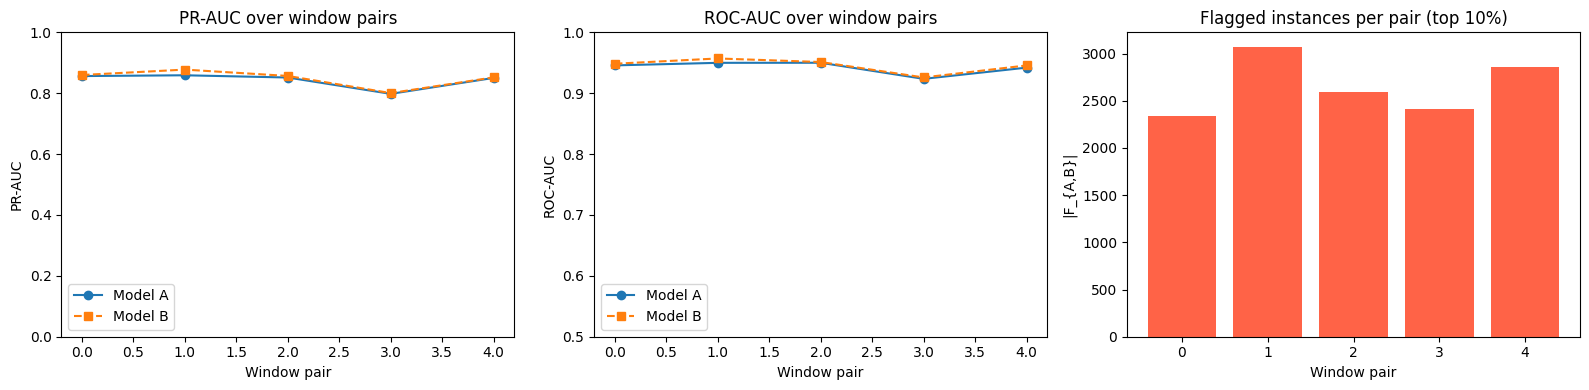

In [8]:
perf_df = pd.DataFrame(performance_log)
print(perf_df.to_string(index=False))
print(f'\nMean PR-AUC  A: {perf_df["pr_auc_A"].mean():.4f}   B: {perf_df["pr_auc_B"].mean():.4f}')
print(f'Mean ROC-AUC A: {perf_df["roc_auc_A"].mean():.4f}   B: {perf_df["roc_auc_B"].mean():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(perf_df['pair_id'], perf_df['pr_auc_A'], 'o-', label='Model A')
axes[0].plot(perf_df['pair_id'], perf_df['pr_auc_B'], 's--', label='Model B')
axes[0].set_title('PR-AUC over window pairs')
axes[0].set_xlabel('Window pair')
axes[0].set_ylabel('PR-AUC')
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].plot(perf_df['pair_id'], perf_df['roc_auc_A'], 'o-', label='Model A')
axes[1].plot(perf_df['pair_id'], perf_df['roc_auc_B'], 's--', label='Model B')
axes[1].set_title('ROC-AUC over window pairs')
axes[1].set_xlabel('Window pair')
axes[1].set_ylabel('ROC-AUC')
axes[1].legend()
axes[1].set_ylim(0.5, 1)

axes[2].bar(perf_df['pair_id'], perf_df['n_flagged'], color='tomato')
axes[2].set_title(f'Flagged instances per pair (top {int(K_FRAC*100)}%)')
axes[2].set_xlabel('Window pair')
axes[2].set_ylabel('|F_{A,B}|')

plt.tight_layout()
plt.savefig(MODEL_DIR / 'performance_over_pairs.png', dpi=120)
plt.show()
